## Turma: DADOS - 2025.2

## Materia: RNA e Deep Learning

### Nome: Wagner Ferreira Porto de Vasconcelos


# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [ ]:
! git clone https://github.com/vcasadei/MNIST.git

fatal: destination path 'MNIST' already exists and is not an empty directory.


In [ ]:
!ls MNIST

processed  raw


In [ ]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [ ]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 200

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 200

Dimensões dos dados das imagens:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [ ]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

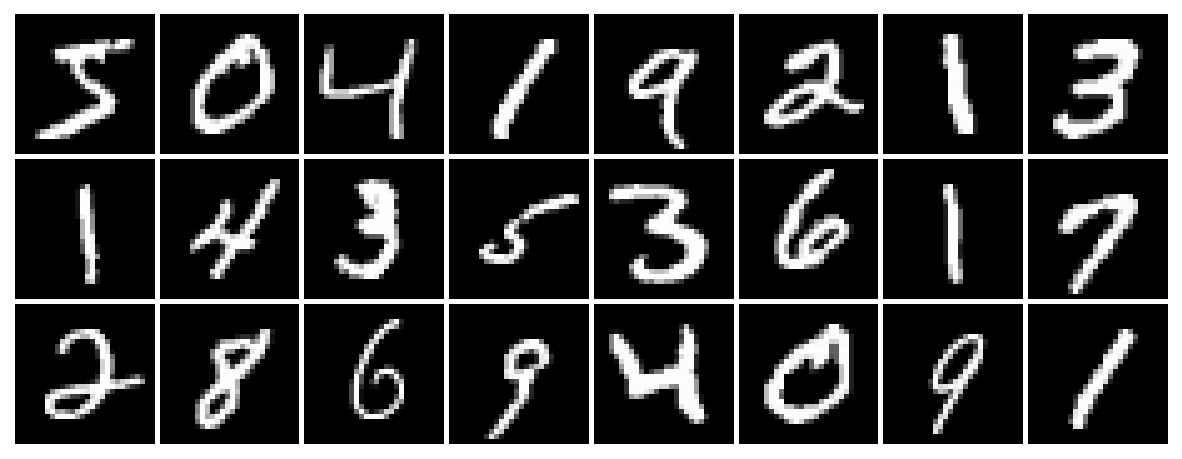

In [ ]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


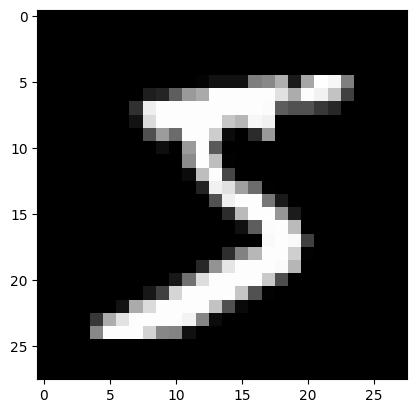

In [ ]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [ ]:
model = torch.nn.Linear(784, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [ ]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[ 7.1537e-02,  2.4351e-02, -1.7666e-02,  4.6497e-02, -1.3938e-01,
         -3.4326e-02, -1.0164e-01,  5.7385e-02,  8.2676e-02,  2.0885e-02],
        [ 4.9301e-01,  1.7151e-01, -1.2089e-01, -2.1113e-01, -3.7565e-01,
          2.8150e-02,  1.3457e-02,  2.3726e-01,  1.9288e-01, -1.5292e-01],
        [-1.5976e-01,  4.9412e-01, -1.1812e-01,  1.0710e-01, -2.6305e-01,
         -8.4870e-02, -5.8694e-02,  4.2602e-02, -3.3447e-05, -1.9764e-01],
        [ 1.4543e-01,  2.9733e-01,  2.3230e-01,  1.0524e-01, -3.0952e-02,
         -4.9591e-02, -9.0284e-02, -2.7201e-02,  3.0041e-01,  7.5315e-02],
        [ 6.7746e-02,  1.3485e-01, -2.0678e-01, -1.7294e-01, -1.0797e-02,
         -9.7590e-03, -6.4046e-02,  4.7324e-02,  1.2132e-01, -9.9578e-02]],
       grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [ ]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [ ]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

#Zera os pesos do modelo
# Reinicializa os parâmetros do modelo para garantir que cada execução comece do zero
torch.nn.init.constant_(model.weight, 0.0)
torch.nn.init.constant_(model.bias, 0.0)

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 2.3026, Train Acc: 0.1050, Val Loss: 1.9268, Val Acc: 0.5050
Epoch [2/100], Train Loss: 1.6716, Train Acc: 0.6900, Val Loss: 1.6078, Val Acc: 0.6300
Epoch [3/100], Train Loss: 1.2899, Train Acc: 0.8100, Val Loss: 1.4560, Val Acc: 0.6300
Epoch [4/100], Train Loss: 1.0441, Train Acc: 0.8400, Val Loss: 1.3230, Val Acc: 0.6550
Epoch [5/100], Train Loss: 0.8833, Train Acc: 0.8750, Val Loss: 1.2416, Val Acc: 0.6400
Epoch [6/100], Train Loss: 0.7673, Train Acc: 0.8900, Val Loss: 1.1813, Val Acc: 0.6850
Epoch [7/100], Train Loss: 0.6839, Train Acc: 0.9000, Val Loss: 1.1333, Val Acc: 0.6850
Epoch [8/100], Train Loss: 0.6205, Train Acc: 0.9100, Val Loss: 1.0971, Val Acc: 0.6850
Epoch [9/100], Train Loss: 0.5699, Train Acc: 0.9200, Val Loss: 1.0661, Val Acc: 0.6850
Epoch [10/100], Train Loss: 0.5280, Train Acc: 0.9300, Val Loss: 1.0400, Val Acc: 0.6900
Epoch [11/100], Train Loss: 0.4924, Train Acc: 0.9350, Val Loss: 1.0175, Val Acc: 0.6950
Epoch [12/100], Train Loss: 0.

In [ ]:
print('Final loss:', loss.item())

Final loss: 0.06193891167640686


### Visualizando gráfico de perda durante o treinamento

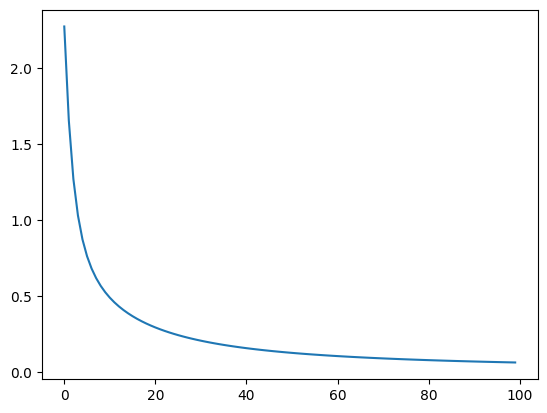

In [ ]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

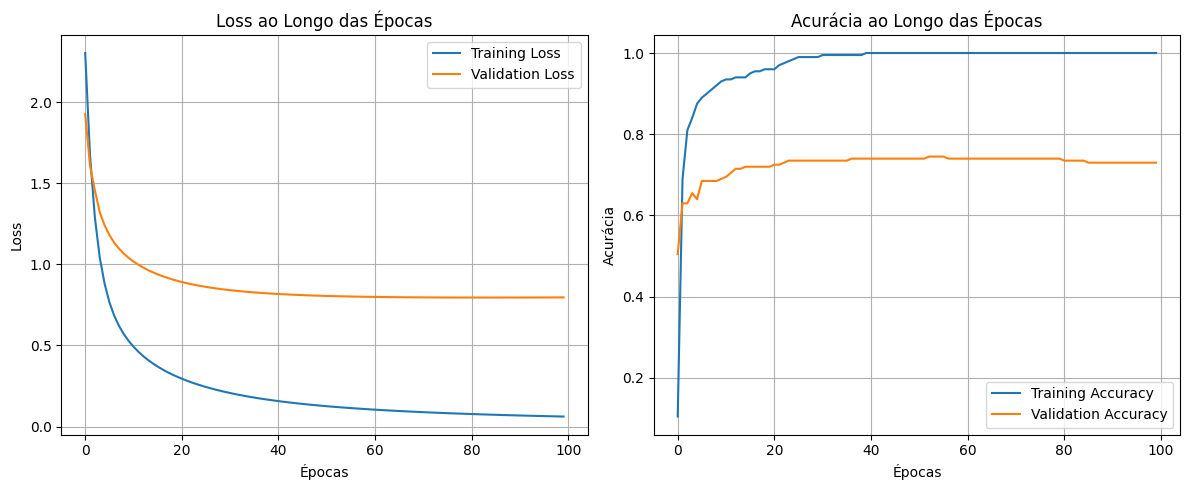

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [ ]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 1.0


### Matriz de confusão com dados de treinamento e teste

In [ ]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,21,0,0,0,0,0,0,0,0,0
1,0,26,0,0,0,0,0,0,0,0
2,0,0,20,0,0,0,0,0,0,0
3,0,0,0,21,0,0,0,0,0,0
4,0,0,0,0,21,0,0,0,0,0
5,0,0,0,0,0,13,0,0,0,0
6,0,0,0,0,0,0,19,0,0,0
7,0,0,0,0,0,0,0,21,0,0
8,0,0,0,0,0,0,0,0,15,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


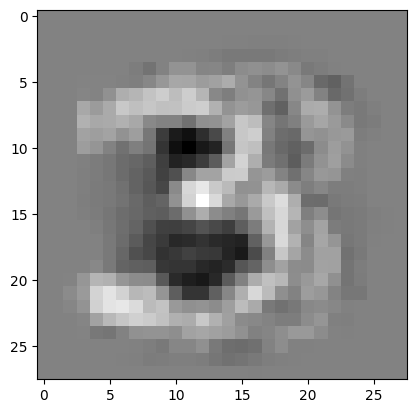

In [ ]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

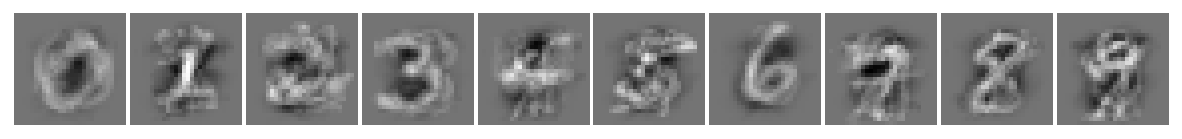

In [ ]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

In [ ]:
losses = []
zs = []

#Zera os pesos do modelo
# Reinicializa os parâmetros do modelo para garantir que cada execução comece do zero
torch.nn.init.constant_(model.weight, 0.0)
torch.nn.init.constant_(model.bias, 0.0)

for i in range(epochs):

    inputs = Variable(x_train.view(-1, 28 * 28))

    outputs = model(inputs)

    zs.append(outputs[1].detach().numpy())

    loss = criterion(outputs, Variable(y_train))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print('Epoch [{}/{}], loss: {:.6f}, acc: {:.6f}'
          .format(i + 1, epochs, loss.item(), accuracy))

Epoch [1/100], loss: 2.302585, acc: 0.105000
Epoch [2/100], loss: 1.671577, acc: 0.690000
Epoch [3/100], loss: 1.289928, acc: 0.810000
Epoch [4/100], loss: 1.044120, acc: 0.840000
Epoch [5/100], loss: 0.883330, acc: 0.875000
Epoch [6/100], loss: 0.767304, acc: 0.890000
Epoch [7/100], loss: 0.683878, acc: 0.900000
Epoch [8/100], loss: 0.620522, acc: 0.910000
Epoch [9/100], loss: 0.569862, acc: 0.920000
Epoch [10/100], loss: 0.527960, acc: 0.930000
Epoch [11/100], loss: 0.492404, acc: 0.935000
Epoch [12/100], loss: 0.461665, acc: 0.935000
Epoch [13/100], loss: 0.434702, acc: 0.940000
Epoch [14/100], loss: 0.410772, acc: 0.940000
Epoch [15/100], loss: 0.389331, acc: 0.940000
Epoch [16/100], loss: 0.369968, acc: 0.950000
Epoch [17/100], loss: 0.352368, acc: 0.955000
Epoch [18/100], loss: 0.336280, acc: 0.955000
Epoch [19/100], loss: 0.321507, acc: 0.960000
Epoch [20/100], loss: 0.307886, acc: 0.960000
Epoch [21/100], loss: 0.295283, acc: 0.960000
Epoch [22/100], loss: 0.283587, acc: 0.9700

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

Epoch [1/100], loss: 2.302585, acc: 0.105000


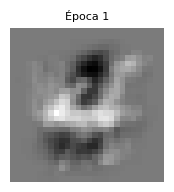

Epoch [2/100], loss: 1.671577, acc: 0.690000


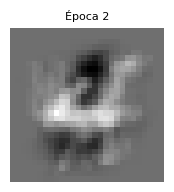

Epoch [3/100], loss: 1.289928, acc: 0.810000


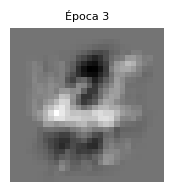

Epoch [4/100], loss: 1.044120, acc: 0.840000


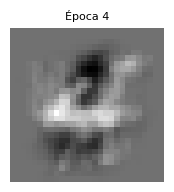

Epoch [5/100], loss: 0.883330, acc: 0.875000


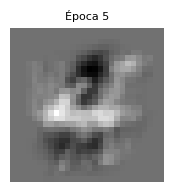

Epoch [6/100], loss: 0.767304, acc: 0.890000


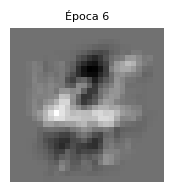

Epoch [7/100], loss: 0.683878, acc: 0.900000


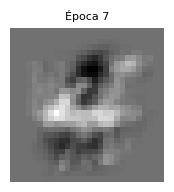

Epoch [8/100], loss: 0.620522, acc: 0.910000


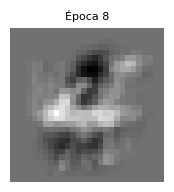

Epoch [9/100], loss: 0.569862, acc: 0.920000


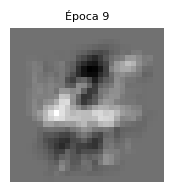

Epoch [10/100], loss: 0.527960, acc: 0.930000


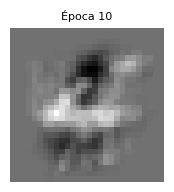

Epoch [11/100], loss: 0.492404, acc: 0.935000


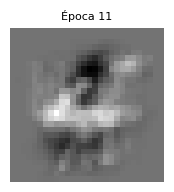

Epoch [12/100], loss: 0.461665, acc: 0.935000


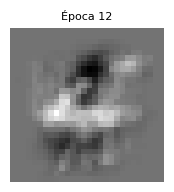

Epoch [13/100], loss: 0.434702, acc: 0.940000


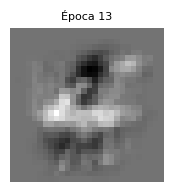

Epoch [14/100], loss: 0.410772, acc: 0.940000


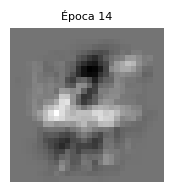

Epoch [15/100], loss: 0.389331, acc: 0.940000


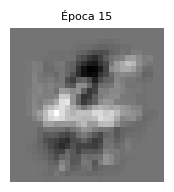

Epoch [16/100], loss: 0.369968, acc: 0.950000


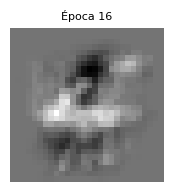

Epoch [17/100], loss: 0.352368, acc: 0.955000


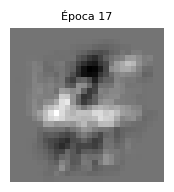

Epoch [18/100], loss: 0.336280, acc: 0.955000


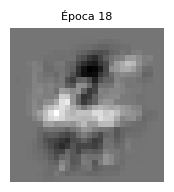

Epoch [19/100], loss: 0.321507, acc: 0.960000


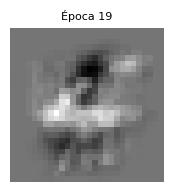

Epoch [20/100], loss: 0.307886, acc: 0.960000


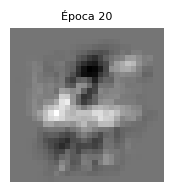

Epoch [21/100], loss: 0.295283, acc: 0.960000


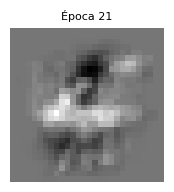

Epoch [22/100], loss: 0.283587, acc: 0.970000


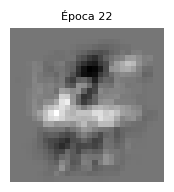

Epoch [23/100], loss: 0.272703, acc: 0.975000


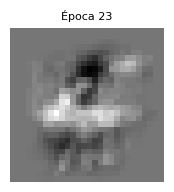

Epoch [24/100], loss: 0.262549, acc: 0.980000


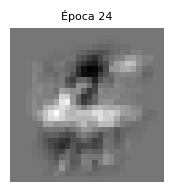

Epoch [25/100], loss: 0.253055, acc: 0.985000


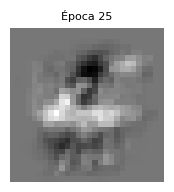

Epoch [26/100], loss: 0.244162, acc: 0.990000


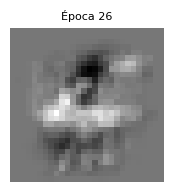

Epoch [27/100], loss: 0.235815, acc: 0.990000


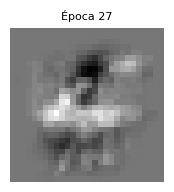

Epoch [28/100], loss: 0.227968, acc: 0.990000


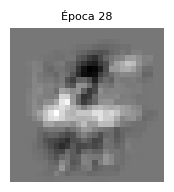

Epoch [29/100], loss: 0.220578, acc: 0.990000


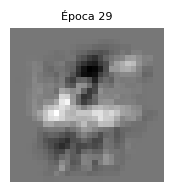

Epoch [30/100], loss: 0.213610, acc: 0.990000


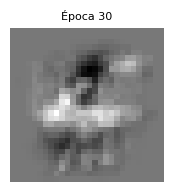

Epoch [31/100], loss: 0.207030, acc: 0.995000


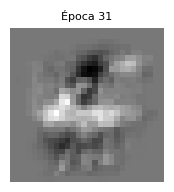

Epoch [32/100], loss: 0.200808, acc: 0.995000


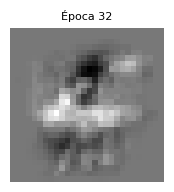

Epoch [33/100], loss: 0.194917, acc: 0.995000


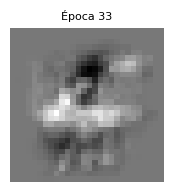

Epoch [34/100], loss: 0.189334, acc: 0.995000


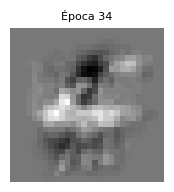

Epoch [35/100], loss: 0.184035, acc: 0.995000


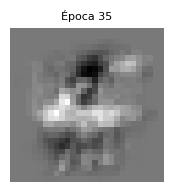

Epoch [36/100], loss: 0.179001, acc: 0.995000


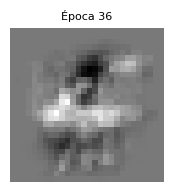

Epoch [37/100], loss: 0.174215, acc: 0.995000


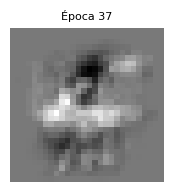

Epoch [38/100], loss: 0.169658, acc: 0.995000


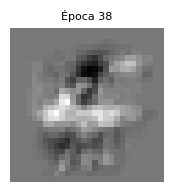

Epoch [39/100], loss: 0.165316, acc: 0.995000


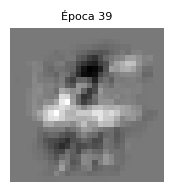

Epoch [40/100], loss: 0.161175, acc: 1.000000


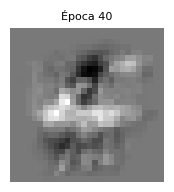

Epoch [41/100], loss: 0.157221, acc: 1.000000


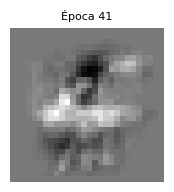

Epoch [42/100], loss: 0.153444, acc: 1.000000


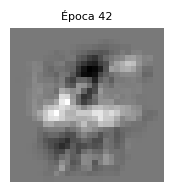

Epoch [43/100], loss: 0.149832, acc: 1.000000


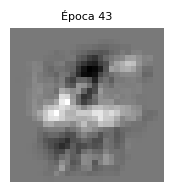

Epoch [44/100], loss: 0.146375, acc: 1.000000


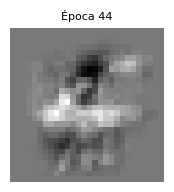

Epoch [45/100], loss: 0.143064, acc: 1.000000


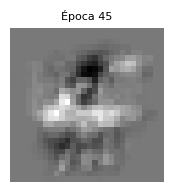

Epoch [46/100], loss: 0.139891, acc: 1.000000


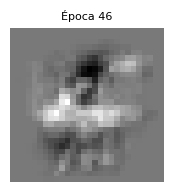

Epoch [47/100], loss: 0.136846, acc: 1.000000


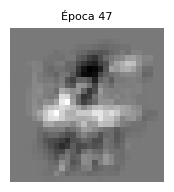

Epoch [48/100], loss: 0.133924, acc: 1.000000


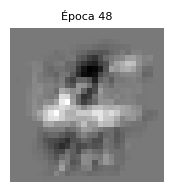

Epoch [49/100], loss: 0.131116, acc: 1.000000


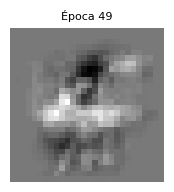

Epoch [50/100], loss: 0.128417, acc: 1.000000


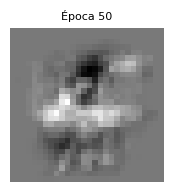

Epoch [51/100], loss: 0.125821, acc: 1.000000


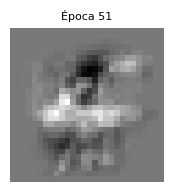

Epoch [52/100], loss: 0.123322, acc: 1.000000


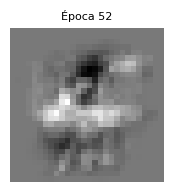

Epoch [53/100], loss: 0.120916, acc: 1.000000


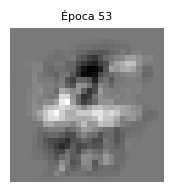

Epoch [54/100], loss: 0.118596, acc: 1.000000


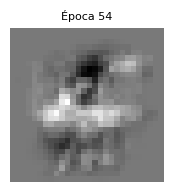

Epoch [55/100], loss: 0.116360, acc: 1.000000


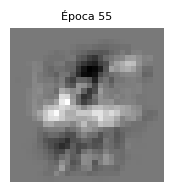

Epoch [56/100], loss: 0.114202, acc: 1.000000


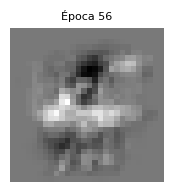

Epoch [57/100], loss: 0.112119, acc: 1.000000


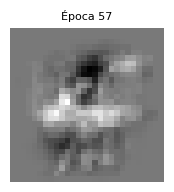

Epoch [58/100], loss: 0.110107, acc: 1.000000


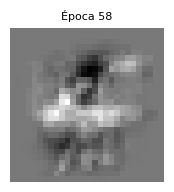

Epoch [59/100], loss: 0.108162, acc: 1.000000


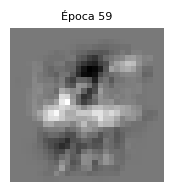

Epoch [60/100], loss: 0.106282, acc: 1.000000


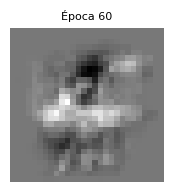

Epoch [61/100], loss: 0.104464, acc: 1.000000


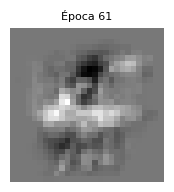

Epoch [62/100], loss: 0.102703, acc: 1.000000


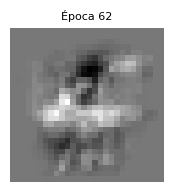

Epoch [63/100], loss: 0.100999, acc: 1.000000


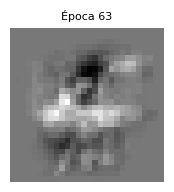

Epoch [64/100], loss: 0.099348, acc: 1.000000


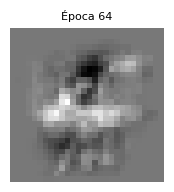

Epoch [65/100], loss: 0.097748, acc: 1.000000


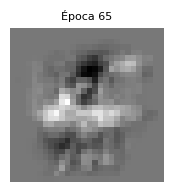

Epoch [66/100], loss: 0.096196, acc: 1.000000


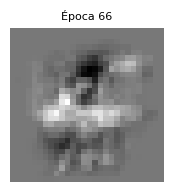

Epoch [67/100], loss: 0.094691, acc: 1.000000


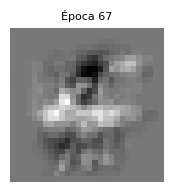

Epoch [68/100], loss: 0.093231, acc: 1.000000


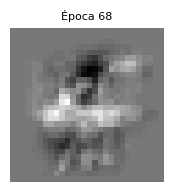

Epoch [69/100], loss: 0.091813, acc: 1.000000


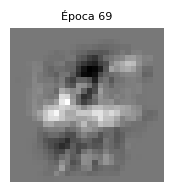

Epoch [70/100], loss: 0.090436, acc: 1.000000


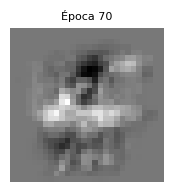

Epoch [71/100], loss: 0.089098, acc: 1.000000


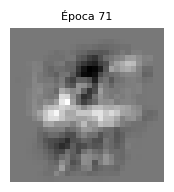

Epoch [72/100], loss: 0.087798, acc: 1.000000


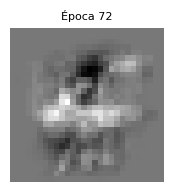

Epoch [73/100], loss: 0.086534, acc: 1.000000


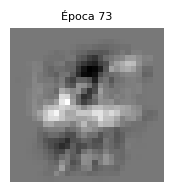

Epoch [74/100], loss: 0.085304, acc: 1.000000


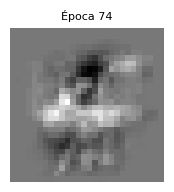

Epoch [75/100], loss: 0.084108, acc: 1.000000


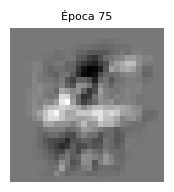

Epoch [76/100], loss: 0.082944, acc: 1.000000


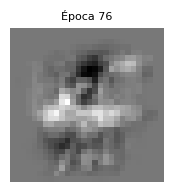

Epoch [77/100], loss: 0.081810, acc: 1.000000


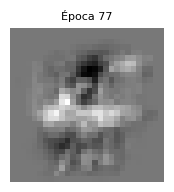

Epoch [78/100], loss: 0.080706, acc: 1.000000


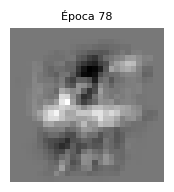

Epoch [79/100], loss: 0.079631, acc: 1.000000


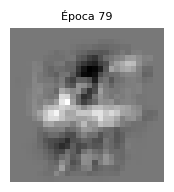

Epoch [80/100], loss: 0.078583, acc: 1.000000


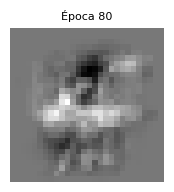

Epoch [81/100], loss: 0.077561, acc: 1.000000


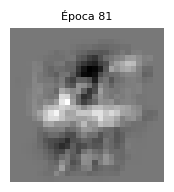

Epoch [82/100], loss: 0.076565, acc: 1.000000


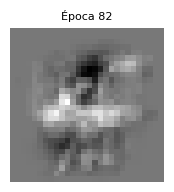

Epoch [83/100], loss: 0.075593, acc: 1.000000


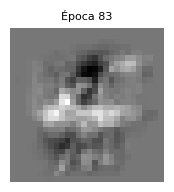

Epoch [84/100], loss: 0.074645, acc: 1.000000


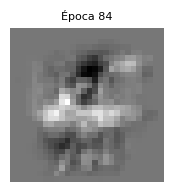

Epoch [85/100], loss: 0.073719, acc: 1.000000


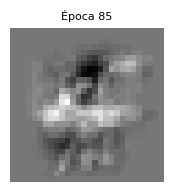

Epoch [86/100], loss: 0.072816, acc: 1.000000


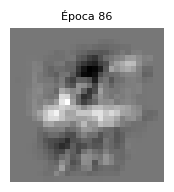

Epoch [87/100], loss: 0.071934, acc: 1.000000


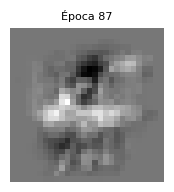

Epoch [88/100], loss: 0.071073, acc: 1.000000


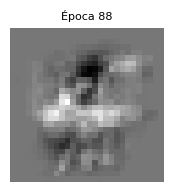

Epoch [89/100], loss: 0.070231, acc: 1.000000


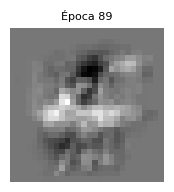

Epoch [90/100], loss: 0.069409, acc: 1.000000


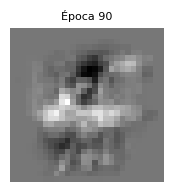

Epoch [91/100], loss: 0.068605, acc: 1.000000


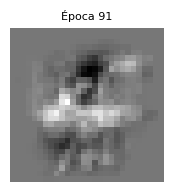

Epoch [92/100], loss: 0.067819, acc: 1.000000


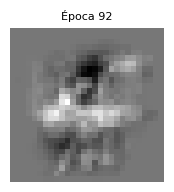

Epoch [93/100], loss: 0.067050, acc: 1.000000


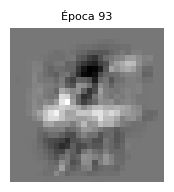

Epoch [94/100], loss: 0.066298, acc: 1.000000


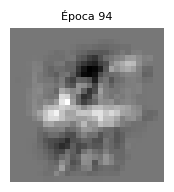

Epoch [95/100], loss: 0.065563, acc: 1.000000


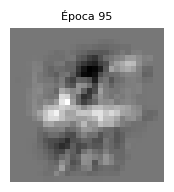

Epoch [96/100], loss: 0.064843, acc: 1.000000


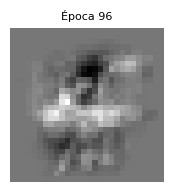

Epoch [97/100], loss: 0.064138, acc: 1.000000


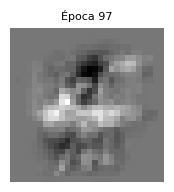

Epoch [98/100], loss: 0.063448, acc: 1.000000


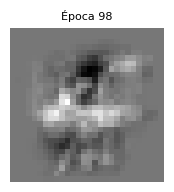

Epoch [99/100], loss: 0.062773, acc: 1.000000


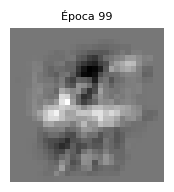

Epoch [100/100], loss: 0.062112, acc: 1.000000


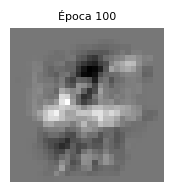

In [ ]:
losses = []
zs = []

#Zera os pesos do modelo
# Reinicializa os parâmetros do modelo para garantir que cada execução comece do zero
torch.nn.init.constant_(model.weight, 0.0)
torch.nn.init.constant_(model.bias, 0.0)

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))

    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # Calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print('Epoch [{}/{}], loss: {:.6f}, acc: {:.6f}'
          .format(i + 1, epochs, loss.item(), accuracy))

    # ✅ Visualiza os pesos (gradientes) do dígito 4 ao final de cada época
    weights = model.state_dict()['weight']
    plt.figure(figsize=(2, 2))  # tamanho em polegadas — reduza à vontade
    plt.imshow(weights[4, :].detach().numpy().reshape(28, 28), cmap='gray')
    plt.title(f'Época {i+1}', fontsize=8)
    plt.axis('off')
    plt.show()


<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?

R: [1,784]

2. Qual é o shape da saída da rede?

R: [1,10]

3. Qual é o número total de parâmetros da rede, incluindo o bias?

R: Parametros 7840 + Bias = 10 = 7850 Parametros

# Aprendizados
